# Машинное обучение, ФКН ВШЭ

## Практическое задание 8. Метод опорных векторов и аппроксимация ядер

### Общая информация

Дата выдачи: 30.01.2025

Мягкий дедлайн: 23:59MSK 16.02.2025

Жесткий дедлайн: 23:59MSK 23.02.2025

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу (без учёта бонусов) — 10 баллов.

Сдавать задание после указанного жёсткого срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):
- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-08-random-features-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

### Примечание
Я понял почему было плохое Accuracy без pca - переполнение при вычислениях. Добавил необходимые тесты и поменял выводы, но не стал полностью менять структуру ноутбука.

Добавил масштабирование к датасету (Зачем, если датасет - картинка, где значения и так одинакового масштаба? да просто чтобы привести их к [0,1], где переполнения не будет). И уменьшил число пар по которым считается сигма до 10000.

### О задании

На занятиях мы подробно обсуждали метод опорных векторов (SVM). В базовой версии в нём нет чего-то особенного — мы всего лишь используем специальную функцию потерь, которая не требует устремлять отступы к бесконечности; ей достаточно, чтобы отступы были не меньше +1. Затем мы узнали, что SVM можно переписать в двойственном виде, который, позволяет заменить скалярные произведения объектов на ядра. Это будет соответствовать построению модели в новом пространстве более высокой размерности, координаты которого представляют собой нелинейные модификации исходных признаков.

Ядровой SVM, к сожалению, довольно затратен по памяти (нужно хранить матрицу Грама размера $d \times d$) и по времени (нужно решать задачу условной оптимизации с квадратичной функцией, а это не очень быстро). Мы обсуждали, что есть способы посчитать новые признаки $\tilde \varphi(x)$ на основе исходных так, что скалярные произведения этих новых $\langle \tilde \varphi(x), \tilde \varphi(z) \rangle$ приближают ядро $K(x, z)$.

Мы будем исследовать аппроксимации методом Random Fourier Features (RFF, также в литературе встречается название Random Kitchen Sinks) для гауссовых ядер. Будем использовать формулы, которые немного отличаются от того, что было на лекциях (мы добавим сдвиги внутрь тригонометрических функций и будем использовать только косинусы, потому что с нужным сдвигом косинус превратится в синус):
$$\tilde \varphi(x) = (
\cos (w_1^T x + b_1),
\dots,
\cos (w_n^T x + b_n)
),$$
где $w_j \sim \mathcal{N}(0, 1/\sigma^2)$, $b_j \sim U[-\pi, \pi]$.

На новых признаках $\tilde \varphi(x)$ мы будем строить любую линейную модель.

Можно считать, что это некоторая новая парадигма построения сложных моделей. Можно направленно искать сложные нелинейные закономерности в данных с помощью градиентного бустинга или нейронных сетей, а можно просто нагенерировать большое количество случайных нелинейных признаков и надеяться, что быстрая и простая модель (то есть линейная) сможет показать на них хорошее качество. В этом задании мы изучим, насколько работоспособна такая идея.

### Алгоритм

Вам потребуется реализовать следующий алгоритм:
1. Понизить размерность выборки до new_dim с помощью метода главных компонент.
2. Для полученной выборки оценить гиперпараметр $\sigma^2$ с помощью эвристики (рекомендуем считать медиану не по всем парам объектов, а по случайному подмножеству из где-то миллиона пар объектов): $$\sigma^2 = \text{median}_{i, j = 1, \dots, \ell, i \neq j} \left\{\sum_{k = 1}^{d} (x_{ik} - x_{jk})^2 \right\}$$
3. Сгенерировать n_features наборов весов $w_j$ и сдвигов $b_j$.
4. Сформировать n_features новых признаков по формулам, приведённым выше.
5. Обучить линейную модель (логистическую регрессию или SVM) на новых признаках.
6. Повторить преобразования (PCA, формирование новых признаков) к тестовой выборке и применить модель.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc

Тестировать алгоритм мы будем на данных Fashion MNIST. Ниже код для их загрузки и подготовки.

In [3]:
import numpy as np

# 1 Способ
import keras
from keras.datasets import fashion_mnist
from sklearn.preprocessing import StandardScaler
(x_train_pics, y_train), (x_test_pics, y_test) = fashion_mnist.load_data()

# 2 Способ (если первый не работает)
# from sklearn.datasets import fetch_openml
# def load_fashion_mnist():
#     X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
#     X = X.reshape(-1, 28, 28).astype('uint8')
#     y = y.astype('int64')
#     x_train, x_test = X[:60000], X[60000:]
#     y_train, y_test = y[:60000], y[60000:]
#     return (x_train, y_train), (x_test, y_test)
# (x_train_pics, y_train), (x_test_pics, y_test) = load_fashion_mnist()




x_train = x_train_pics.reshape(y_train.shape[0], -1)
x_test = x_test_pics.reshape(y_test.shape[0], -1)
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

__Задание 0. (0.25 баллов)__

**Вопрос:** зачем в алгоритме нужен метод главных компонент?

**Ответ:**  Самое очевидное, что после использования PCA возрастет скорость рассчета необходимой нам матрицы новых признаков. Так как нам нужно будет генерировать меньшее количество весов и умножать их на меньшие векторы объектов. При этом в силу того, что PCA выделит главные компоненты, результаты ухудшаться не сильно. Если его не использовать, то рассчитывание новой матрицы признаков займет O(dnl), где d - кол-во старых признаков, n - количество сгенерированных RFF призаков, l - количество объектов. Помимо того, память, без использования PCA весов для рассчета признаков становится очень много, из-за чего на практике колаб падал.

Отдельно отметим, что RFF устроен так, что вклад отдельных признаков утрачивается из-за рандомизации и взятия косинуса, поэтому применение PCA более чем оправдано.


__Задание 1. (3 балла)__

Реализуйте алгоритм, описанный выше. Можете воспользоваться шаблоном класса в `homework_practice_08_rff.py` (допишите его и исправьте несостыковки в классе пайплайна) или написать свой интерфейс.

Ваша реализация должна поддерживать следующие опции:
1. Возможность задавать значения гиперпараметров new_dim (по умолчанию 50) и n_features (по умолчанию 1000).
2. Возможность включать или выключать предварительное понижение размерности с помощью метода главных компонент.
3. Возможность выбирать тип линейной модели (логистическая регрессия или SVM с линейным ядром).

Протестируйте на данных Fashion MNIST, сформированных кодом выше. Если на тесте у вас получилась доля верных ответов не ниже 0.84 с гиперпараметрами по умолчанию, то вы всё сделали правильно.

In [4]:
from homework_practice_08_rff import RFFPipeline, RandomFeatureCreator
from sklearn.metrics import accuracy_score

pipeline = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=RandomFeatureCreator)

In [ ]:
pipeline.fit(x_train, y_train)
print(accuracy_score(y_test, pipeline.predict(x_test)))
gc.collect()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8555


54

__Задание 2. (2.5 балла)__

Сравните подход со случайными признаками с обучением SVM на исходных признаках. Попробуйте вариант с обычным (линейным) SVM и с ядровым SVM. Ядровой SVM может очень долго обучаться, поэтому можно делать любые разумные вещи для ускорения: брать подмножество объектов из обучающей выборки, например.

Сравните подход со случайными признаками с вариантом, в котором вы понижаете размерность с помощью PCA и обучите градиентный бустинг. Используйте одну из реализаций CatBoost/LightGBM/XGBoost.

Сделайте выводы — насколько идея со случайными признаками работает? Сравните как с точки зрения качества, так и с точки зрения скорости обучения и применения.

Для ускорения вычислений, рассчет всего был выполнен на об. выборке в 10000 объектов.

In [5]:
from sklearn.svm import SVC, LinearSVC
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score
metrics = pd.DataFrame(columns=['Model','Accuracy', 'Learning time', 'Predicting time'])
metrics

,Model,Accuracy,Learning time,Predicting time


In [ ]:
#SVM с RFF
%%time
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator, classifier_class=LinearSVC, use_PCA=False)
pipeline.fit(x_train[:10000], y_train[:10000])
print('Done')

Done
CPU times: user 2min 2s, sys: 607 ms, total: 2min 2s
Wall time: 2min 8s


In [ ]:
%%time
y_pred = pipeline.predict(x_test)

CPU times: user 1.26 s, sys: 167 ms, total: 1.42 s
Wall time: 1.4 s


In [ ]:
metrics.loc[0] = ['SVM+RFF', accuracy_score(y_test, y_pred), 125, 0.884]
gc.collect()

0

In [ ]:
#Linear SVM
%%time
model = LinearSVC()
model.fit(x_train[:10000], y_train[:10000])
print('Done')

Done
CPU times: user 8min 31s, sys: 692 ms, total: 8min 32s
Wall time: 8min 43s


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
%%time
y_pred = model.predict(x_test)

CPU times: user 46.2 ms, sys: 1.99 ms, total: 48.2 ms
Wall time: 27.8 ms


In [ ]:
metrics.loc[1] = ['Linear SVM', accuracy_score(y_test, model.predict(x_test)), 430, 0.047]
gc.collect()

0

In [ ]:
#SVM с RFF+PCA
%%time
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator, classifier_class=LinearSVC)
pipeline.fit(x_train[:10000], y_train[:10000])
print('Done')

Done
CPU times: user 4min 2s, sys: 813 ms, total: 4min 3s
Wall time: 4min 3s


In [ ]:
%%time
y_pred = pipeline.predict(x_test)

CPU times: user 497 ms, sys: 204 ms, total: 701 ms
Wall time: 461 ms


In [ ]:
metrics.loc[2] = ['SVM+RFF+PCA', accuracy_score(y_test, pipeline.predict(x_test)), 85, 0.449]

In [ ]:
#kernel SVM
%%time
model = SVC()
model.fit(x_train[:10000], y_train[:10000])
print('Done')

Done
CPU times: user 14.9 s, sys: 70.8 ms, total: 15 s
Wall time: 15 s


In [ ]:
%%time
y_pred = model.predict(x_test)

CPU times: user 51.8 s, sys: 32.8 ms, total: 51.8 s
Wall time: 52.1 s


In [ ]:
metrics.loc[3] = ['Kernel SVM', accuracy_score(y_test, pipeline.predict(x_test)), 9.55, 45.9]
gc.collect()

0

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier

In [ ]:
#Catboost
%%time
model = CatBoostClassifier(iterations=30,
                          depth=3)
model.fit(x_train[:10000], y_train[:10000])
print('Done')

Learning rate set to 0.5
0:	learn: 1.5245778	total: 612ms	remaining: 17.7s
1:	learn: 1.2782622	total: 952ms	remaining: 13.3s
2:	learn: 1.0881126	total: 1.35s	remaining: 12.2s
3:	learn: 0.9752735	total: 1.72s	remaining: 11.2s
4:	learn: 0.8916521	total: 2.07s	remaining: 10.3s
5:	learn: 0.8356719	total: 2.44s	remaining: 9.74s
6:	learn: 0.7986709	total: 2.76s	remaining: 9.07s
7:	learn: 0.7730244	total: 3.08s	remaining: 8.48s
8:	learn: 0.7333296	total: 3.5s	remaining: 8.16s
9:	learn: 0.7048788	total: 3.88s	remaining: 7.76s
10:	learn: 0.6800437	total: 4.33s	remaining: 7.49s
11:	learn: 0.6636289	total: 4.87s	remaining: 7.31s
12:	learn: 0.6535790	total: 5.49s	remaining: 7.18s
13:	learn: 0.6427892	total: 6.12s	remaining: 6.99s
14:	learn: 0.6254291	total: 6.69s	remaining: 6.69s
15:	learn: 0.6185339	total: 7.25s	remaining: 6.34s
16:	learn: 0.6108176	total: 7.56s	remaining: 5.78s
17:	learn: 0.6012943	total: 7.92s	remaining: 5.28s
18:	learn: 0.5976381	total: 8.21s	remaining: 4.76s
19:	learn: 0.5883

In [ ]:
%%time
y_pred = model.predict(x_test)

CPU times: user 2.71 s, sys: 22.9 ms, total: 2.74 s
Wall time: 2.71 s


In [ ]:
metrics.loc[4] = ['Catboost', accuracy_score(y_test, model.predict(x_test)), 23.6, 2.6]
gc.collect()

0

In [ ]:
#Catboost + PCA
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
pipeline = Pipeline([('pca', PCA(n_components=50)), ('classifier', CatBoostClassifier(iterations=30))])

In [ ]:
%%time
pipeline.fit(x_train[:10000], y_train[:10000])

Learning rate set to 0.5
0:	learn: 1.3037397	total: 248ms	remaining: 7.19s
1:	learn: 1.0360999	total: 512ms	remaining: 7.17s
2:	learn: 0.9510204	total: 668ms	remaining: 6.01s
3:	learn: 0.8507813	total: 811ms	remaining: 5.27s
4:	learn: 0.7741097	total: 953ms	remaining: 4.77s
5:	learn: 0.7263377	total: 1.09s	remaining: 4.38s
6:	learn: 0.6891683	total: 1.23s	remaining: 4.05s
7:	learn: 0.6594994	total: 1.37s	remaining: 3.77s
8:	learn: 0.6238163	total: 1.52s	remaining: 3.54s
9:	learn: 0.6001391	total: 1.68s	remaining: 3.35s
10:	learn: 0.5847153	total: 1.83s	remaining: 3.16s
11:	learn: 0.5579087	total: 1.97s	remaining: 2.96s
12:	learn: 0.5388467	total: 2.12s	remaining: 2.77s
13:	learn: 0.5214277	total: 2.26s	remaining: 2.58s
14:	learn: 0.5031589	total: 2.4s	remaining: 2.4s
15:	learn: 0.4841419	total: 2.54s	remaining: 2.23s
16:	learn: 0.4703131	total: 2.7s	remaining: 2.07s
17:	learn: 0.4612147	total: 2.85s	remaining: 1.9s
18:	learn: 0.4537821	total: 2.99s	remaining: 1.73s
19:	learn: 0.4452055

Pipeline(steps=[('pca', PCA(n_components=50)),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x7ab6acbb2ad0>)])

In [ ]:
%%time
y_pred = pipeline.predict(x_test)

CPU times: user 326 ms, sys: 105 ms, total: 431 ms
Wall time: 294 ms


In [ ]:
metrics.loc[5] = ['Catboost+PCA', accuracy_score(y_test, pipeline.predict(x_test)), 6.35, 0.309]

In [ ]:
metrics

,Model,Accuracy,Learning time,Predicting time
0,SVM+RFF,0.8108,125.00,0.884
1,Linear SVM,0.7857,430.00,0.047
2,SVM+RFF+PCA,0.8467,85.00,0.449
3,Kernel SVM,0.8467,9.55,45.900
4,Catboost,0.7892,23.60,2.600
5,Catboost+PCA,0.7975,6.35,0.309


При наличии PCA случайные признаки работают очень хорошо, не уступая ядровому SVM в качестве. Кроме того, быстрее считают предсказания, но дольше обучаются (вероятно либо из-за подсчета сигмы, либо из-за багованной реалиазции linear svm). Без PCA случайные признаки ухудшают качество и уступают в скорости.

При пересчете на скорость Catboost значительно их лучше, но уступает в качестве. Однако, не был произведен подбор параметров, поэтому наверняка о качестве сказать нельзя.

__Задание 3. (2 балла)__

Проведите эксперименты:
1. Помогает ли предварительное понижение размерности с помощью PCA?
2. Как зависит итоговое качество от n_features? Выходит ли оно на плато при росте n_features?
3. Важно ли, какую модель обучать — логистическую регрессию или SVM?

In [ ]:
# Помогает ли предварительное понижение размерности с помощью PCA?
# Сравним logreg с rff на тестовой выборке по accuracy
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator, use_PCA=False)
pipeline.fit(x_train, y_train)
print("LogReg + RFF:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + RFF: 0.8603


In [ ]:
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator)
pipeline.fit(x_train, y_train)
print("LogReg + RFF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + RFF + PCA: 0.8588


На логистической регрессии и большей выборке эффект оказался обратный. PCA снизил точность.

In [ ]:
#Сократим выборку для большей скорости и построим график для анализа
dim = np.arange(10, 500, 50)
acc = []
for new_dim in dim:
  pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator, new_dim=new_dim)
  pipeline.fit(x_train[:10000], y_train[:10000])
  acc.append(accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Text(0, 0.5, 'Accuracy')

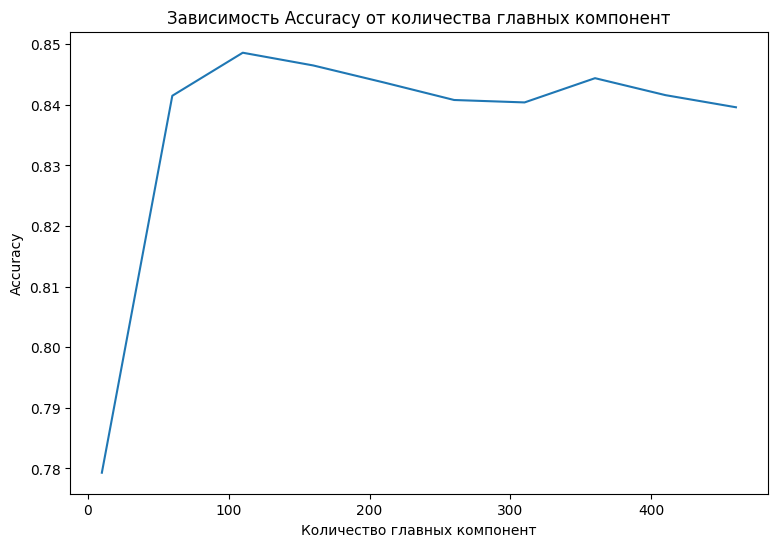

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Зависимость Accuracy от количества главных компонент')
ax.plot(dim, acc)
ax.set_xlabel('Количество главных компонент')
ax.set_ylabel('Accuracy')

Видим, что сначала качество быстро возрастает, а затем медленно убывает (возможно не статзначимо).

Понятное дело, рост связан с потерей информации от выбрасывания слишком большого числа компонент.

Убывание может быть связано с потерей точностей при вычислении большого числа признаков.

In [7]:
#Как зависит итоговое качество от n_features? Выходит ли оно на плато при росте n_features?
#Аналогично предыдущему
feu = np.arange(100, 5000, 100)
acc = []
for n_feu in feu:
  pipeline = RFFPipeline(n_features=n_feu, feature_creator_class=RandomFeatureCreator)
  pipeline.fit(x_train[:10000], y_train[:10000])
  acc.append(accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Text(0, 0.5, 'Accuracy')

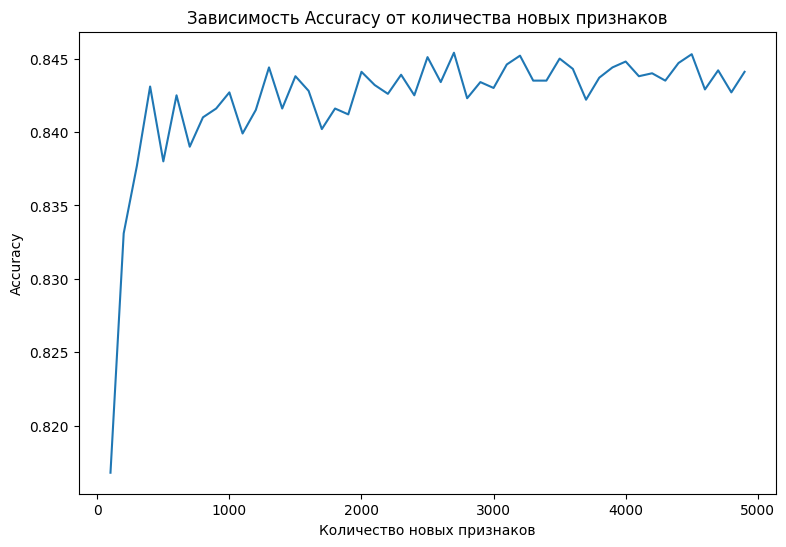

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Зависимость Accuracy от количества новых признаков')
ax.plot(feu, acc)
ax.set_xlabel('Количество новых признаков')
ax.set_ylabel('Accuracy')

Зависит положительно, выходя на плато, где происходят не статзначимые колебания.

In [12]:
#Важно ли, какую модель обучать — логистическую регрессию или SVM?
#Дообучим SVM на всей выборке и сравним качество.
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator, classifier_class=LinearSVC)
pipeline.fit(x_train, y_train)
print("SVM + RFF:",accuracy_score(y_test, pipeline.predict(x_test)))

SVM + RFF: 0.8781


Предположим, что разница статзначима. SVM лучше, возможно, так как он способствует меньшему variance.

__Задание 4. (Максимум 1.5 балла)__

Как вы, должно быть, помните с курса МО-1, многие алгоритмы машинного обучения работают лучше, если признаки данных некоррелированы. Оказывается, что для RFF существует модификация, позволяющая получать ортогональные случайные признаки (Orthogonal Random Features, ORF). Об этом методе можно прочитать в [статье](https://proceedings.neurips.cc/paper/2016/file/53adaf494dc89ef7196d73636eb2451b-Paper.pdf). Реализуйте класс для вычисления ORF по аналогии с основным заданием. Обратите внимание, что ваш класс должен уметь работать со случаем n_features > new_dim (в статье есть замечание на этот счет), n_features=new_dim и n_features < new_dim также должны работать, убедитесь в этом. Проведите эксперименты, сравнивающие RFF и ORF, сделайте выводы.


In [13]:
#Тестируем случаи
#n_features > new_dim
from homework_practice_08_rff import OrthogonalRandomFeatureCreator

pipeline = RFFPipeline(n_features=1000, feature_creator_class=OrthogonalRandomFeatureCreator)
pipeline.fit(x_train[:5000], y_train[:5000])
print("LogReg + ORF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + ORF + PCA: 0.83


In [14]:
#n_features = new_dim
pipeline = RFFPipeline(n_features=500, new_dim=500, feature_creator_class=OrthogonalRandomFeatureCreator)
pipeline.fit(x_train[:5000], y_train[:5000])
print("LogReg + ORF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + ORF + PCA: 0.8232


In [15]:
#n_features < new_dim
pipeline = RFFPipeline(n_features=100, new_dim=500, feature_creator_class=OrthogonalRandomFeatureCreator)
pipeline.fit(x_train[:5000], y_train[:5000])
print("LogReg + ORF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + ORF + PCA: 0.7853


Работает, теперь сравним с RFF.

In [16]:
# Эксперимент 1. Сравним работу базовых моделей с PCA
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator)
pipeline.fit(x_train[:10000], y_train[:10000])
print("Logreg + RFF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))
pipeline = RFFPipeline(n_features=1000, feature_creator_class=OrthogonalRandomFeatureCreator)
pipeline.fit(x_train[:10000], y_train[:10000])
print("LogReg + ORF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logreg + RFF + PCA: 0.8419


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + ORF + PCA: 0.8425


In [6]:
# Эксперимент 2. Сравним работу базовых моделей без PCA
from homework_practice_08_rff import OrthogonalRandomFeatureCreator
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator, use_PCA = False)
pipeline.fit(x_train[:5000], y_train[:5000])
print("Logreg + RFF:",accuracy_score(y_test, pipeline.predict(x_test)))
pipeline = RFFPipeline(n_features=1000, feature_creator_class=OrthogonalRandomFeatureCreator, use_PCA = False)
pipeline.fit(x_train[:5000], y_train[:5000])
print("LogReg + ORF:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logreg + RFF: 0.8255


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + ORF: 0.8198


In [9]:
# Эксперимент 3. Сравним работу PCA+SVM
from sklearn.svm import SVC, LinearSVC
from homework_practice_08_rff import OrthogonalRandomFeatureCreator
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator, classifier_class=LinearSVC)
pipeline.fit(x_train[:10000], y_train[:10000])
print("SVM + RFF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))
pipeline = RFFPipeline(n_features=1000, feature_creator_class=OrthogonalRandomFeatureCreator, classifier_class=LinearSVC)
pipeline.fit(x_train[:10000], y_train[:10000])
print("SVM + ORF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

SVM + RFF + PCA: 0.8471
SVM + ORF + PCA: 0.8453


Я бы сказал, что разница не статзначима, но в среднем RFF показал себя лучше, плюс и работает быстрее.

__Задание 5. (Максимум 1 балл)__

Существует большое количество работ, где идея RFF развивается, предлагаются её обобщения (которые, по сути, выливаются в другие преобразования признаков, не обязательно уже тригонометрические). Возьмите любую из таких работ, кратко опишите идею, имплементируйте её и сравните качество с ORF и RFF, которые вы запрограммировали выше.

Ссылки на статьи, где обсуждаются вариации RFF для разных ядер, можно найти в окрестности таблицы 1 в работе https://arxiv.org/pdf/1407.5599  

___ссылка на работу:___ http://proceedings.mlr.press/v22/kar12/kar12.pdf

___описание идеи:___

**Имеется**: ядро вида $K(x,y) = f(<x,y>)$, d старых признаков

**Хотим**: получить преобразование Z: $<Z(x), Z(y)> \approx K(x,y)$, D новых признаков

Находим формулу для получения константы $a_n$ при n-ом члене в ряде Маклорена

Фиксируем гиперпараметр p>1

Повторяем D раз:
1. Генерим число N, где $P(N = n) = \frac{1}{p^{n+1}}$
2. Генерим N векторов $w_i \in \{-1, 1\}^d$, посредством бернулли с вероятностью 0.5
3. D-й признак: $\sqrt{a_N p^{N+1}} \prod_i^N w_j^T x$

Реализуем для экспоненциального ядра: $exp(\frac{<x,y>}{\sigma^2})$



In [10]:
#тест
from homework_practice_08_rff import RFFPipeline, RandomFeatureCreator, RandomMaclaurinFeatureCreator
from sklearn.metrics import accuracy_score

pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomMaclaurinFeatureCreator)
pipeline.fit(x_train[:10000], y_train[:10000])
print("Logreg + RMF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logreg + RMF + PCA: 0.8138


In [11]:
#сравним по времени и качеству
%%time
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomMaclaurinFeatureCreator)
pipeline.fit(x_train[:10000], y_train[:10000])
print("Done")

Done
CPU times: user 20.6 s, sys: 4.11 s, total: 24.7 s
Wall time: 14.3 s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
%%time
print("Logreg + RMF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

Logreg + RMF + PCA: 0.813
CPU times: user 336 ms, sys: 231 ms, total: 567 ms
Wall time: 286 ms


In [13]:
%%time
pipeline = RFFPipeline(n_features=1000, feature_creator_class=RandomFeatureCreator)
pipeline.fit(x_train[:10000], y_train[:10000])
print("Done")

Done
CPU times: user 19.6 s, sys: 3.86 s, total: 23.5 s
Wall time: 13.6 s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
%%time
print("Logreg + RFF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

Logreg + RFF + PCA: 0.8419
CPU times: user 544 ms, sys: 141 ms, total: 685 ms
Wall time: 648 ms


In [15]:
from homework_practice_08_rff import OrthogonalRandomFeatureCreator

In [16]:
%%time
pipeline = RFFPipeline(n_features=1000, feature_creator_class=OrthogonalRandomFeatureCreator)
pipeline.fit(x_train[:10000], y_train[:10000])
print("Done")

Done
CPU times: user 19.5 s, sys: 3.43 s, total: 22.9 s
Wall time: 13.4 s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
%%time
print("LogReg + ORF + PCA:",accuracy_score(y_test, pipeline.predict(x_test)))

LogReg + ORF + PCA: 0.8451
CPU times: user 540 ms, sys: 139 ms, total: 679 ms
Wall time: 683 ms


ORF и RFF имеют примерно одинаковое качество, RMF чуть хуже. По времени обучения лучше всех RFF, чуть хуже RMF, а ORF существенно отстает. По выдаче ответов ORF и RFF одинаковы, RMF хуже.

Вероятно, RMF хуже по качеству, так как приближает экспоненциальное ядро, а не гауссово.

__Задание 6. (Максимум 2.5 балла)__

Реализуйте класс ядровой Ridge регрессии (Лекция 13, $\S 1.2$), для оптимизации используте градиентный спуск **[1 балл максимум]**, также добавьте возможность использовать аналитическую формулу **[1 балл максимум]**. Для градиентного спуска выпишите градиент ниже **[0.5 баллов максимум]**.
Подумайте о том, как в формулах правильно учесть свободный коэффициент.

Затем адаптируйте вашу реализацию RFF под задачу регрессии. Сравните вашу ядровую регрессию и RFF на синтетических данных.

Функция потерь:
$$
Q(w) = \frac{1}{2} ||\Phi \Phi^T w - y||^2 + \frac{\lambda}{2} w^T \Phi \Phi^T w \rightarrow \min_w,
$$
где $\Phi \Phi^T = K$, $K = (k(x_i, x_j))_{i, j = 1}^{\ell}$.

Предсказание:
$
y(x) = k(x)^T w,
$
где $k(x)$ — вектор функций ядра от пар объектов $(x, x_i)_{i=1}^{\ell}$.

___Выведите градиент:___
$$
dQ(w) = \frac{1}{2} d||\Phi \Phi^T w - y||^2 + \frac{\lambda}{2} d(w^T \Phi \Phi^T w) = \frac{1}{2} d<\Phi \Phi^T w - y, \Phi \Phi^T w - y> + \frac{\lambda}{2} ((dw)^T \Phi \Phi^T w + w^T \Phi \Phi^T dw ) = <\Phi \Phi^T w - y, \Phi \Phi^T dw> + \lambda <\Phi \Phi^T w, dw> \overset{\Phi \Phi^T \text{-симметрична}}{=} <\Phi \Phi^T(\Phi \Phi^T w - y), dw> + \lambda <\Phi \Phi^T w, dw> = <\Phi \Phi^T(\Phi \Phi^T w - y) + \lambda \Phi \Phi^T w, dw>
$$
$$
\nabla Q(w) = \Phi \Phi^T(\Phi \Phi^T w - y) + \lambda \Phi \Phi^T w = K(Kw - y) + \lambda Kw
$$

Вы можете изменять представленный шаблон в файле `homework_practice_08_kernel_regression.py` по своему усмотрению.

In [ ]:
from homework_practice_08_kernel_regression import KernelRidgeRegression
from homework_practice_08_rff import RFFPipeline, RandomFeatureCreator, RandomMaclaurinFeatureCreator, RFFPipelineRegressor

import matplotlib.pyplot as plt
from sklearn.datasets import  make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=10000, n_features=200, noise=1, random_state=42)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
#Тестируем ридж
%%time
model = KernelRidgeRegression()
model.fit(x_train,y_train)



CPU times: user 1min 37s, sys: 8.42 s, total: 1min 46s
Wall time: 1min 13s


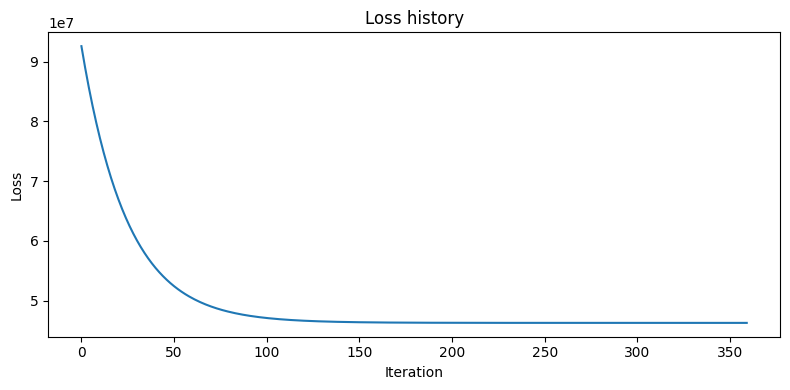

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.loss_history)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss history')
plt.tight_layout()
plt.show()

In [ ]:
%%time
print("Train MSE:", mean_squared_error(model.predict(x_train),y_train))
print("Test MSE:", mean_squared_error(model.predict(x_test),y_test))

Train MSE: 6920.188964485919
Test MSE: 26290.402830964464
CPU times: user 10.2 s, sys: 988 ms, total: 11.2 s
Wall time: 11.9 s


In [ ]:
#Напрямую высчитываем
%%time
model = KernelRidgeRegression()
model.fit_closed_form(x_train,y_train)


CPU times: user 52.7 s, sys: 1.71 s, total: 54.4 s
Wall time: 34.6 s


In [ ]:
%%time
print("Train MSE:", mean_squared_error(model.predict(x_train),y_train))
print("Test MSE:", mean_squared_error(model.predict(x_test),y_test))

Train MSE: 6910.398283312387
Test MSE: 26290.402830964464
CPU times: user 10.4 s, sys: 438 ms, total: 10.8 s
Wall time: 10.7 s


In [ ]:
#RFF
%%time
model = RFFPipelineRegressor(n_features=1000, feature_creator_class=RandomFeatureCreator)
model.fit(x_train,y_train)
print('Done')

Done
CPU times: user 1.38 s, sys: 545 ms, total: 1.93 s
Wall time: 1.67 s


In [ ]:
%%time
print("Train MSE:", mean_squared_error(model.predict(x_train),y_train))
print("Test MSE:", mean_squared_error(model.predict(x_test),y_test))

Train MSE: 15415.623632579473
Test MSE: 21151.94051416846
CPU times: user 470 ms, sys: 209 ms, total: 679 ms
Wall time: 701 ms


Пока можем точно сказать, что rff работают существенно быстрее. И на удивление лучше показывают себя на тесте, но так как мы не подбирали гиперпараметры сказать ничего точно нельзя. Сократим немного датасет для большей скорости и подберем гиперпараметры optuna.

In [ ]:
%pip install optuna

In [ ]:
X, y = make_regression(n_samples=6000, n_features=120, noise=1, random_state=42)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

In [ ]:
import optuna
from warnings import simplefilter
simplefilter("ignore", category=RuntimeWarning)
def objective(trial, model="custom_boosting"):
    params = {
        "regularization": trial.suggest_float("regularization", 0.1, 10),
        "lr": trial.suggest_float("lr", 0.1, 1),
        "kernel_scale":trial.suggest_float("kernel_scale", 0.1, 5)
    }
    np.random.seed(1337)
    model = KernelRidgeRegression(**params)
    model.fit(x_train, y_train)
    pred = model.predict(x_val)
    if np.any(np.isnan(pred)):
      return np.inf
    return mean_squared_error(y_val, pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, timeout=600)

print("Best params:", study.best_params)
print("Best loss:", study.best_value)

In [ ]:
model = KernelRidgeRegression(**study.best_params)
model.fit(x_train,y_train)
print("Train MSE:", mean_squared_error(model.predict(x_train),y_train))
print("Test MSE:", mean_squared_error(model.predict(x_test),y_test))

Train MSE: 13361.99964765076
Test MSE: 43378.18214447765


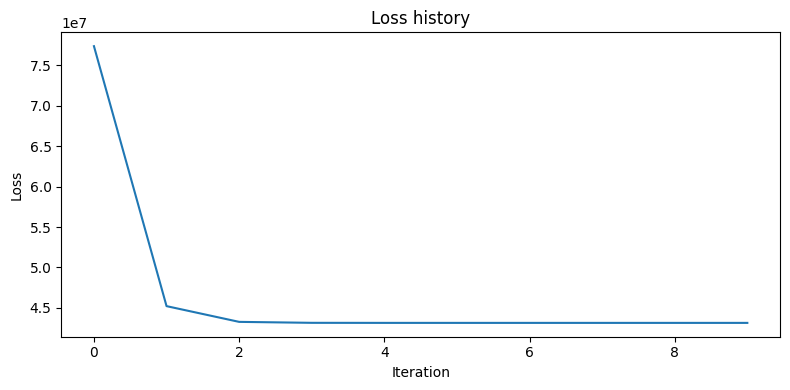

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.loss_history)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss history')
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from warnings import simplefilter
simplefilter("ignore", category=RuntimeWarning)
def objective(trial, model="custom_boosting"):
    params = {"regression_params":{"alpha":trial.suggest_float("alpha", 0.1, 10)},
              "n_features": trial.suggest_int("n_features", 100, 3000),
              "new_dim":trial.suggest_int("new_dim", 5, 100)}
    np.random.seed(1337)
    model = RFFPipelineRegressor(**params)
    model.fit(x_train, y_train)
    pred = model.predict(x_val)
    if np.any(np.isnan(pred)):
      return np.inf
    return mean_squared_error(y_val, pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, timeout=600)

print("Best params:", study.best_params)
print("Best loss:", study.best_value)

In [ ]:
model = RFFPipelineRegressor(regression_params={'alpha':2.956201000413633}, n_features=1332, new_dim=100)
model.fit(x_train,y_train)
print("Train MSE:", mean_squared_error(model.predict(x_train),y_train))
print("Test MSE:", mean_squared_error(model.predict(x_test),y_test))

Train MSE: 3084.7798753675092
Test MSE: 4265.811559279886


In [ ]:
import optuna
from warnings import simplefilter
simplefilter("ignore", category=RuntimeWarning)
def objective(trial, model="custom_boosting"):
    params = {
        "regularization": trial.suggest_float("regularization", 0.1, 10),
        "kernel_scale":trial.suggest_float("kernel_scale", 0.1, 5)
    }
    np.random.seed(1337)
    model = KernelRidgeRegression(**params)
    model.fit_closed_form(x_train, y_train)
    pred = model.predict(x_val)
    if np.any(np.isnan(pred)):
      return np.inf
    return mean_squared_error(y_val, pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, timeout=600)

print("Best params:", study.best_params)
print("Best loss:", study.best_value)

[I 2025-02-15 20:13:04,986] A new study created in memory with name: no-name-332878fc-73d8-48fa-ac7f-7a125ff4fa09
[I 2025-02-15 20:13:10,736] Trial 0 finished with value: 38794.82612236752 and parameters: {'regularization': 5.99140408808383, 'kernel_scale': 1.8773453731173166}. Best is trial 0 with value: 38794.82612236752.
[I 2025-02-15 20:13:17,890] Trial 1 finished with value: 38794.81780033734 and parameters: {'regularization': 8.548707999172546, 'kernel_scale': 2.237801780017991}. Best is trial 1 with value: 38794.81780033734.
[I 2025-02-15 20:13:23,641] Trial 2 finished with value: 38794.82613956819 and parameters: {'regularization': 4.676452370924471, 'kernel_scale': 1.1446219806633706}. Best is trial 1 with value: 38794.81780033734.
[I 2025-02-15 20:13:32,870] Trial 3 finished with value: 38794.826134646544 and parameters: {'regularization': 5.421414396956481, 'kernel_scale': 1.8195950934970575}. Best is trial 1 with value: 38794.81780033734.
[I 2025-02-15 20:13:39,260] Trial 4

Best params: {'regularization': 0.16921168726517952, 'kernel_scale': 4.956848445696485}
Best loss: 10138.776302485172


In [ ]:
model = KernelRidgeRegression(**study.best_params)
model.fit_closed_form(x_train,y_train)
print("Train MSE:", mean_squared_error(model.predict(x_train),y_train))
print("Test MSE:", mean_squared_error(model.predict(x_test),y_test))

Train MSE: 260.0167387335542
Test MSE: 12159.510921371068


Можем сделать вывод, что:


1.   Градиентный спуск для ядер - плохая идея, значительно сильнее падает качество
2.   Ядерный метод сильно склонен к переобучению. У него минимальная ошибка на обучающей выборке, при большей ошибке на тестовой.
3. Ядерный метод очень медленный.
4. Метод со случайными признаками показал себя отлично. Быстро и хорошее качество.

Почему это может быть так, если случайные признаки - обобщение? Я бы предположил, что засчет того, что для них лучше подобрались параметры, так как оптуна банально больше трайалов обработала (из-за быстрой скорости).
